## Анализ обращений в техподдержку интернет-провайдера

**Тема:** Разработка хранилища данных для анализа обращений в техподдержку интернет-провайдера  
**Исследовательский вопрос:**  
Влияет ли рост нагрузки на оператора на его эффективность, то есть сокращается ли средняя длительность звонка и изменяется ли доля
тикетов, закрытых на линии, при увеличении количества обработанных звонков?

**Метрики:**
- `OperatorLoad` — количество звонков, обработанных оператором за день;
- `AvgCallDuration` — средняя длительность звонка (сек);
- `ResolvedOnLineRate` — доля тикетов, закрытых на линии (%).

In [27]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from db_config import DB_CONFIG

# Стиль графиков: тёмная сетка, читаемые подписи
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"   # корректная кириллица
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# Папка для сохранения картинок
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [28]:
def query(sql: str) -> pd.DataFrame:
    """Выполняет SQL-запрос и возвращает DataFrame."""
    with pymysql.connect(**DB_CONFIG) as conn:
        return pd.read_sql(sql, conn)

### 1. Проверка данных

Проверим, что загруженные данные соответствуют ожиданиям:
- средняя длительность звонка близка к 5 минутам;
- доля решённых на линии около 50–55%;
- распределение по типам проблем соответствует модели нагрузки.

In [29]:
df_overview = query("""
    SELECT
        COUNT(*)                              AS TotalTickets,
        ROUND(AVG(CallDurationSeconds), 0)    AS AvgDurationSec,
        ROUND(AVG(CallDurationSeconds)/60, 2) AS AvgDurationMin,
        ROUND(AVG(ResolutionTimeHours), 2)    AS AvgResolutionHours,
        ROUND(SUM(Resolved)/COUNT(*)*100, 1)  AS ResolvedPct
    FROM FactTickets
""")
df_overview

C:\Users\Name\AppData\Local\Temp\ipykernel_4884\2321577462.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,TotalTickets,AvgDurationSec,AvgDurationMin,AvgResolutionHours,ResolvedPct
0,81370,293.0,4.89,9.23,98.2


In [30]:
df_groups = query("""
    SELECT
        g.GroupName,
        COUNT(*) AS Tickets,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM FactTickets), 1) AS Pct
    FROM FactTickets f
    JOIN DimAssignmentGroup g ON f.AssignmentGroupKey = g.GroupKey
    GROUP BY g.GroupName
    ORDER BY Tickets DESC
""")
df_groups

C:\Users\Name\AppData\Local\Temp\ipykernel_4884\2321577462.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,GroupName,Tickets,Pct
0,Закрыто на линии,43515,53.5
1,Мастер,12930,15.9
2,Офисные инженеры,8956,11.0
3,Внутренняя заявка,8188,10.1
4,Восстановительная бригада,5104,6.3
5,Мастер в деревне,2677,3.3


In [31]:
df_problems = query("""
    SELECT
        p.ProblemTypeName,
        COUNT(*)                               AS Tickets,
        ROUND(AVG(f.CallDurationSeconds), 0)   AS AvgDurationSec,
        ROUND(SUM(f.Resolved)/COUNT(*)*100, 1) AS ResolvedPct
    FROM FactTickets f
    JOIN DimProblemType p ON f.ProblemTypeKey = p.ProblemTypeKey
    GROUP BY p.ProblemTypeName
    ORDER BY Tickets DESC
""")
df_problems

C:\Users\Name\AppData\Local\Temp\ipykernel_4884\2321577462.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,ProblemTypeName,Tickets,AvgDurationSec,ResolvedPct
0,Проверка интернета,20532,303.0,99.0
1,Низкая скорость,12176,302.0,97.6
2,Настройка роутера,12171,302.0,98.4
3,Неработающее оборудование по адресу,8188,221.0,100.0
4,Вопросы IPTV,8150,301.0,98.6
5,Повреждение кабеля,8006,299.0,96.0
6,Вопросы по сетевой настройке,7991,303.0,97.9
7,Дополнительные платные услуги мастера,4156,297.0,94.9


Общее число тикетов за год - 81370. Средняя продолжительность звонка практически равна 5 минутам, а доля решённых на линии вопросов более 95%, т.к. часть решаются гарантированно, и только 5% от оставшихся остаются. На линии решается чуть более 50% вопросов, а преобладающие типы проблем аналогично заданным при генерации. Данные соответствуют ожиданиям.

### 2. Основная агрегация «оператор-день»

Покажем работу оператора в отдельные дни, превратив тикеты в рабочие смены. На этом уровне агрегации можно исследовать, как нагрузка влияет на эффективность.

In [32]:
SQL_OPERATOR_DAY = """
    SELECT
        f.OperatorKey,
        o.Name     AS OperatorName,
        o.Category AS OperatorCategory,
        f.DateKey,
        d.FullDate,
        d.DayOfWeek,
        d.DayName,
        COUNT(*)                                                  AS OperatorLoad,
        AVG(f.CallDurationSeconds)                                AS AvgCallDuration,
        SUM(CASE WHEN g.GroupName = 'Закрыто на линии' THEN 1 ELSE 0 END)
                                                                  AS ResolvedOnLine,
        SUM(CASE WHEN g.GroupName = 'Закрыто на линии' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*)                                    AS ResolvedOnLineRate
    FROM FactTickets f
    JOIN DimOperator        o ON f.OperatorKey        = o.OperatorKey
    JOIN DimDate            d ON f.DateKey            = d.DateKey
    JOIN DimAssignmentGroup g ON f.AssignmentGroupKey = g.GroupKey
    GROUP BY
        f.OperatorKey, o.Name, o.Category,
        f.DateKey, d.FullDate, d.DayOfWeek, d.DayName
"""

df_shifts = query(SQL_OPERATOR_DAY)

# Приводим типы
df_shifts["FullDate"] = pd.to_datetime(df_shifts["FullDate"])
df_shifts["AvgCallDuration"] = df_shifts["AvgCallDuration"].astype(float)
df_shifts["ResolvedOnLineRate"] = df_shifts["ResolvedOnLineRate"].astype(float)

print(f"Всего смен: {len(df_shifts)}")
print(f"Операторов: {df_shifts['OperatorKey'].nunique()}")
print(f"Дней: {df_shifts['DateKey'].nunique()}")
df_shifts.head(10)

C:\Users\Name\AppData\Local\Temp\ipykernel_4884\2321577462.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


Всего смен: 2924
Операторов: 8
Дней: 731


,OperatorKey,OperatorName,OperatorCategory,DateKey,FullDate,DayOfWeek,DayName,OperatorLoad,AvgCallDuration,ResolvedOnLine,ResolvedOnLineRate
0,1,Иванова Анна Сергеевна,3,20240101,2024-01-01,1,Понедельник,16,388.5625,7.0,43.75000
1,1,Иванова Анна Сергеевна,3,20240103,2024-01-03,3,Среда,58,319.6207,36.0,62.06897
2,1,Иванова Анна Сергеевна,3,20240104,2024-01-04,4,Четверг,10,390.0000,4.0,40.00000
3,1,Иванова Анна Сергеевна,3,20240107,2024-01-07,7,Воскресенье,20,337.7500,12.0,60.00000
4,1,Иванова Анна Сергеевна,3,20240111,2024-01-11,4,Четверг,36,374.0556,21.0,58.33333
5,1,Иванова Анна Сергеевна,3,20240112,2024-01-12,5,Пятница,31,375.6452,21.0,67.74194
6,1,Иванова Анна Сергеевна,3,20240113,2024-01-13,6,Суббота,59,290.6271,29.0,49.15254
7,1,Иванова Анна Сергеевна,3,20240114,2024-01-14,7,Воскресенье,22,326.7727,14.0,63.63636
8,1,Иванова Анна Сергеевна,3,20240115,2024-01-15,1,Понедельник,23,360.7391,13.0,56.52174
9,1,Иванова Анна Сергеевна,3,20240116,2024-01-16,2,Вторник,34,349.1471,24.0,70.58824


In [33]:
df_shifts[["OperatorLoad", "AvgCallDuration", "ResolvedOnLineRate"]].describe().round(2)

,OperatorLoad,AvgCallDuration,ResolvedOnLineRate
count,2924.00,2924.00,2924.00
mean,27.83,310.39,55.22
std,17.58,48.73,14.36
min,1.00,154.85,0.00
25%,14.00,275.34,45.45
50%,25.00,308.83,54.84
75%,38.00,343.35,64.10
max,114.00,481.33,100.00


Общее число смен более 2900 - это два года по 4 оператора за день.

### 3. Связь нагрузки с показателями эффективности

**Гипотеза**:
При росте нагрузки на оператора:
- средняя длительность звонка сокращается (спешка);
- доля тикетов, закрытых на линии, меняется (уменьшается).

Метрики считаются на уровне «оператор-день», то есть одна точка —
это одна рабочая смена одного оператора.

In [34]:
import numpy as np

# Коэффициенты корреляции Пирсона
r_load_dur = np.corrcoef(df_shifts["OperatorLoad"], df_shifts["AvgCallDuration"])[0, 1]
r_load_res = np.corrcoef(df_shifts["OperatorLoad"], df_shifts["ResolvedOnLineRate"])[0, 1]

print("Корреляция Пирсона (n = {}):".format(len(df_shifts)))
print(f"  OperatorLoad - AvgCallDuration:    r = {r_load_dur:+.3f}")
print(f"  OperatorLoad - ResolvedOnLineRate: r = {r_load_res:+.3f}")

# Матрица корреляций для наглядности
corr_matrix = df_shifts[["OperatorLoad", "AvgCallDuration", "ResolvedOnLineRate"]] \
                .corr(method="pearson").round(3)
corr_matrix

Корреляция Пирсона (n = 2924):
  OperatorLoad - AvgCallDuration:    r = -0.553
  OperatorLoad - ResolvedOnLineRate: r = -0.192


,OperatorLoad,AvgCallDuration,ResolvedOnLineRate
OperatorLoad,1.000,-0.553,-0.192
AvgCallDuration,-0.553,1.000,0.517
ResolvedOnLineRate,-0.192,0.517,1.000


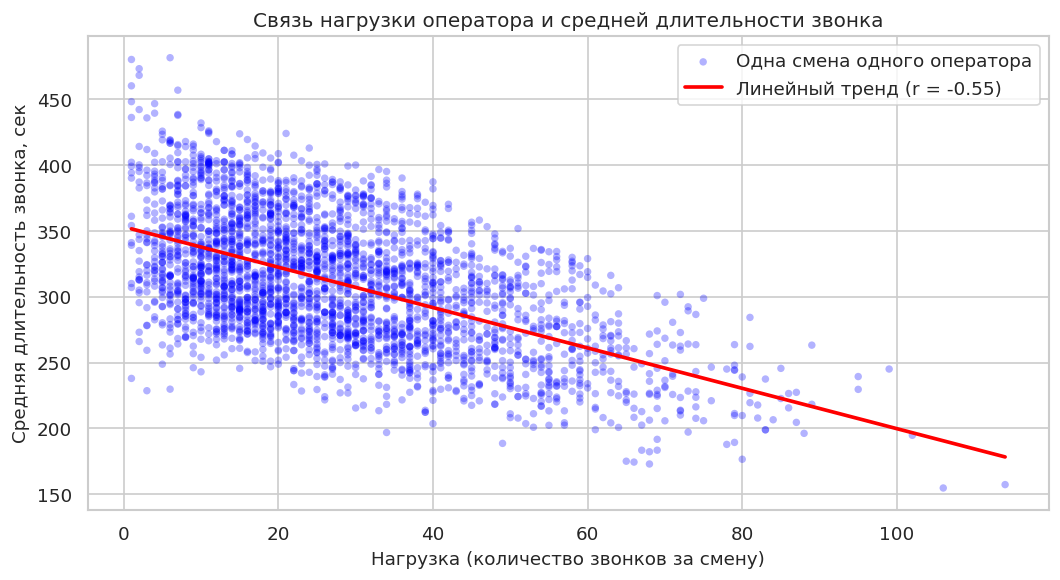

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

# Облако точек
ax.scatter(
    df_shifts["OperatorLoad"],
    df_shifts["AvgCallDuration"],
    alpha=0.30, s=20, color="blue", edgecolors="none",
    label="Одна смена одного оператора",
)

# Линия тренда (линейная регрессия), использует коэффициент корреляции
coef = np.polyfit(df_shifts["OperatorLoad"], df_shifts["AvgCallDuration"], 1)
xs = np.linspace(df_shifts["OperatorLoad"].min(), df_shifts["OperatorLoad"].max(), 100)
ax.plot(xs, np.polyval(coef, xs), color="red", linewidth=2.2,
        label=f"Линейный тренд (r = {r_load_dur:+.2f})")

ax.set_title("Связь нагрузки оператора и средней длительности звонка")
ax.set_xlabel("Нагрузка (количество звонков за смену)")
ax.set_ylabel("Средняя длительность звонка, сек")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "load_vs_duration.png", dpi=150, bbox_inches="tight")
plt.show()

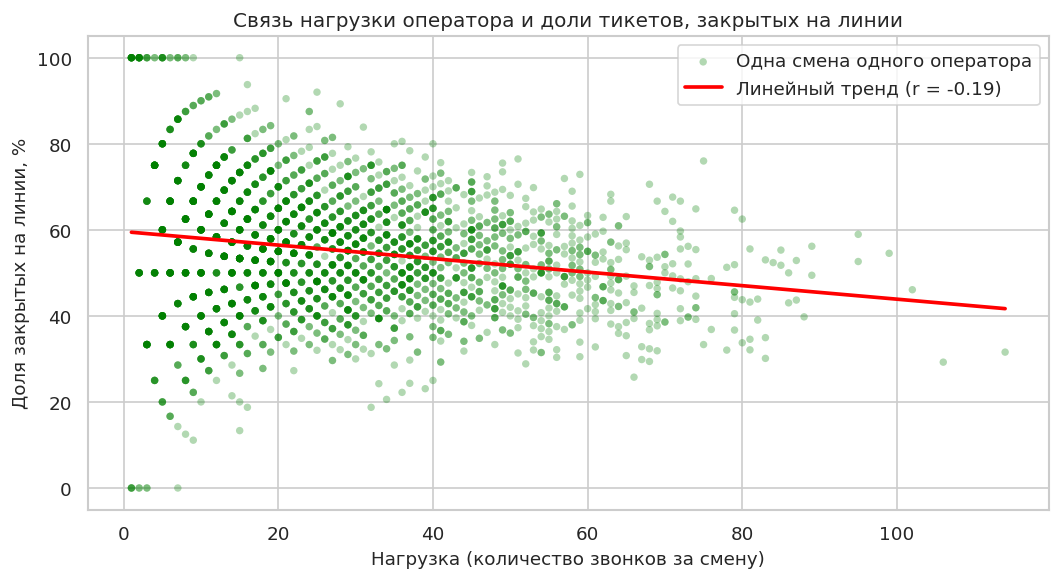

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# Облако точек
ax.scatter(
    df_shifts["OperatorLoad"],
    df_shifts["ResolvedOnLineRate"],
    alpha=0.30, s=20, color="green", edgecolors="none",
    label="Одна смена одного оператора",
)

# Линия тренда (линейная регрессия), использует коэффициент корреляции
coef = np.polyfit(df_shifts["OperatorLoad"], df_shifts["ResolvedOnLineRate"], 1)
xs = np.linspace(df_shifts["OperatorLoad"].min(), df_shifts["OperatorLoad"].max(), 100)
ax.plot(xs, np.polyval(coef, xs), color="red", linewidth=2.2,
        label=f"Линейный тренд (r = {r_load_res:+.2f})")

ax.set_title("Связь нагрузки оператора и доли тикетов, закрытых на линии")
ax.set_xlabel("Нагрузка (количество звонков за смену)")
ax.set_ylabel("Доля закрытых на линии, %")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "load_vs_resolved.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# Разбиваем смены на три равные группы по нагрузке (терцили)
df_shifts["LoadTertile"] = pd.qcut(
    df_shifts["OperatorLoad"],
    q=3,
    labels=["Низкая", "Средняя", "Высокая"],
)

# Агрегируем метрики по группам
df_tert = (
    df_shifts
    .groupby("LoadTertile", observed=True)
    .agg(
        Shifts=("OperatorLoad", "count"),
        AvgLoad=("OperatorLoad", "mean"),
        MinLoad=("OperatorLoad", "min"),
        MaxLoad=("OperatorLoad", "max"),
        AvgDuration=("AvgCallDuration", "mean"),
        AvgResolvedRate=("ResolvedOnLineRate", "mean"),
    )
    .round(2)
)
df_tert

,Shifts,AvgLoad,MinLoad,MaxLoad,AvgDuration,AvgResolvedRate
LoadTertile,,,,,,
Низкая,983,10.58,1,17,336.00,57.66
Средняя,992,25.07,18,33,315.49,55.75
Высокая,949,48.57,34,114,278.54,52.15


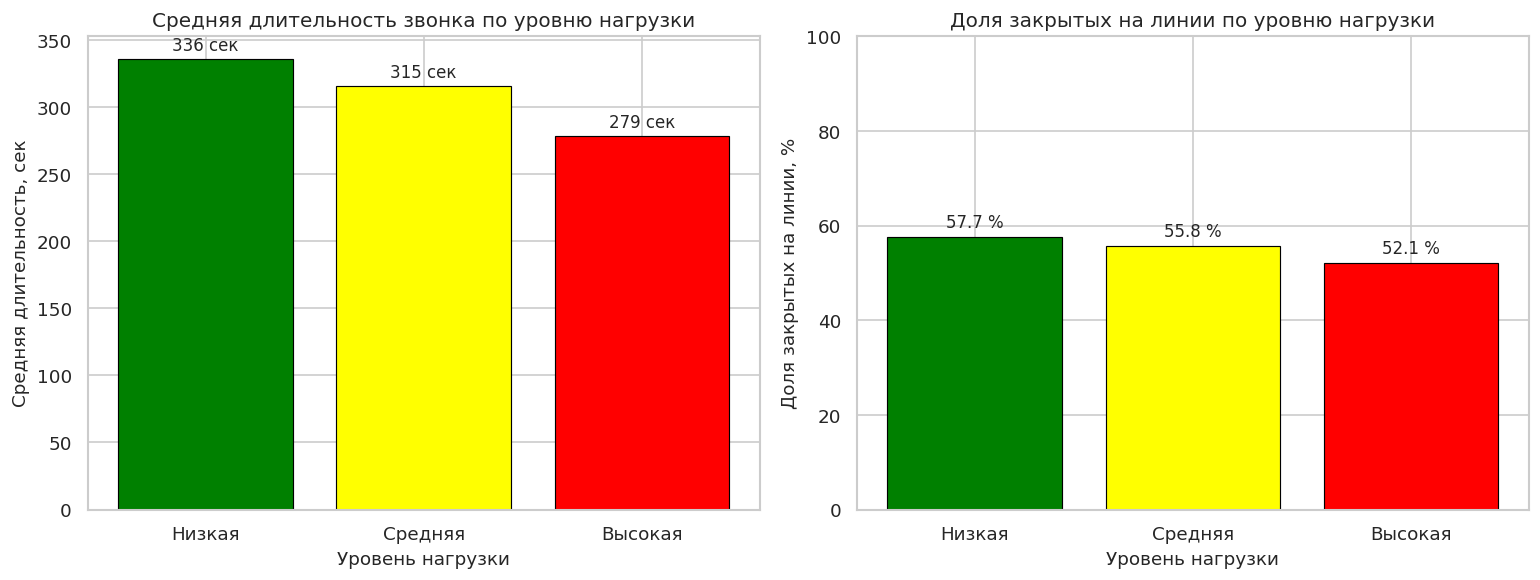

In [ ]:
load_labels = df_tert.index.tolist()   # ['Низкая', 'Средняя', 'Высокая']
colors = ["green", "yellow", "red"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Средняя длительность
bars1 = axes[0].bar(
    load_labels, df_tert["AvgDuration"],
    color=colors, edgecolor="black", linewidth=0.7,
)
axes[0].bar_label(bars1, fmt="%.0f сек", padding=3, fontsize=10)
axes[0].set_title("Средняя длительность звонка по уровню нагрузки")
axes[0].set_xlabel("Уровень нагрузки")
axes[0].set_ylabel("Средняя длительность, сек")

# Доля решённых на линии
bars2 = axes[1].bar(
    load_labels, df_tert["AvgResolvedRate"],
    color=colors, edgecolor="black", linewidth=0.7,
)
axes[1].bar_label(bars2, fmt="%.1f %%", padding=3, fontsize=10)
axes[1].set_title("Доля закрытых на линии по уровню нагрузки")
axes[1].set_xlabel("Уровень нагрузки")
axes[1].set_ylabel("Доля закрытых на линии, %")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIG_DIR / "tertiles_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Выводы по исследовательскому вопросу

Результаты анализа подтверждают гипотезу о влиянии нагрузки на эффективность оператора.

Коэффициент корреляции Пирсона между нагрузкой и средней длительностью звонка составил r = −0.55, что свидетельствует о выраженной отрицательной связи. При переходе от низкой нагрузки (в среднем 10.6 звонков за смену) к высокой (48.6 звонков) средняя длительность сокращается с 336 до 278 секунд — почти на 17 %.

Менее значительное влияние оказывается на долю закрытий в линии, корреляция составляет −0.19. При том же росте нагрузки показатель падает с 57.7% до 52.2%, его монотонность, в том числе графическая, подтверждают отрицательную связь нагрузки и доли закрытия тикетов.

Механизмом влияния является связь длительности звонка с долей закрытий на линии: их корреляция положительна и составляет +0.52. То есть чем дольше оператор общается с клиентом, тем чаще решает вопрос без передачи в поле. Нагрузка влияет на качество косвенно - через сокращение времени диалога.

Таким образом, при росте нагрузки для сохранения качества (закрытие около половины тикетов в линии) оператор платит за это сокращением времени на разговор. В качестве бизнес-методов решения данной проблемы можно предложить введение дополнительного оператора в часы пиковой нагрузки - это должно позитивно сказаться и на длительности разговора, и на доле решённых на линии обращений.